# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [11]:
import pandas as pd

file_path = r"C:\Users\96650\Downloads\Sadaia_AI\Student\Exercises\Week3\auto-mpg.data"

rows = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        parts = line.split(maxsplit=8)   # أول 8 أعمدة + الباقي car_name
        
        if len(parts) == 9:
            rows.append(parts)

df = pd.DataFrame(rows, columns=[
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
])

# تحويل الأعمدة الرقمية
numeric_cols = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.head())
print(df.shape)
print(df.dtypes)

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                     car_name  
0          70       1  "chevrolet chevelle malibu"  
1          70       1          "buick skylark 320"  
2          70       1         "plymouth satellite"  
3          70       1              "amc rebel sst"  
4          70       1                "ford torino"  
(398, 9)
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name            str
dtype: object


In [12]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,"""chevrolet chevelle malibu"""
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,"""buick skylark 320"""
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,"""plymouth satellite"""
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,"""amc rebel sst"""
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,"""ford torino"""


### Step 2.a Assign variables `X` to the features and `y` to the target

In [13]:
X = df.drop(columns=["mpg","car name"], errors="ignore")
y = df["mpg"]


In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (398, 8)
y shape: (398,)


### Step 2.b print the type of each

In [15]:
print(type(X))
print(type(y))


<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [16]:
print("\nTarget is numerical")
print("Task is Regression")



Target is numerical
Task is Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [18]:
print("Shape of X:", X.shape)

print("Shape of y:", y.shape)

print("\nNumber of samples:", X.shape[0])

print("Number of feature columns:", X.shape[1])

Shape of X: (398, 8)
Shape of y: (398,)

Number of samples: 398
Number of feature columns: 8


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [19]:
# Step 4 summary
summary = X.describe()
print(summary)



        cylinders  displacement  horsepower       weight  acceleration  \
count  398.000000    398.000000  392.000000   398.000000    398.000000   
mean     5.454774    193.425879  104.469388  2970.424623     15.568090   
std      1.701004    104.269838   38.491160   846.841774      2.757689   
min      3.000000     68.000000   46.000000  1613.000000      8.000000   
25%      4.000000    104.250000   75.000000  2223.750000     13.825000   
50%      4.000000    148.500000   93.500000  2803.500000     15.500000   
75%      8.000000    262.000000  126.000000  3608.000000     17.175000   
max      8.000000    455.000000  230.000000  5140.000000     24.800000   

       model_year      origin  
count  398.000000  398.000000  
mean    76.010050    1.572864  
std      3.697627    0.802055  
min     70.000000    1.000000  
25%     73.000000    1.000000  
50%     76.000000    1.000000  
75%     79.000000    2.000000  
max     82.000000    3.000000  


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

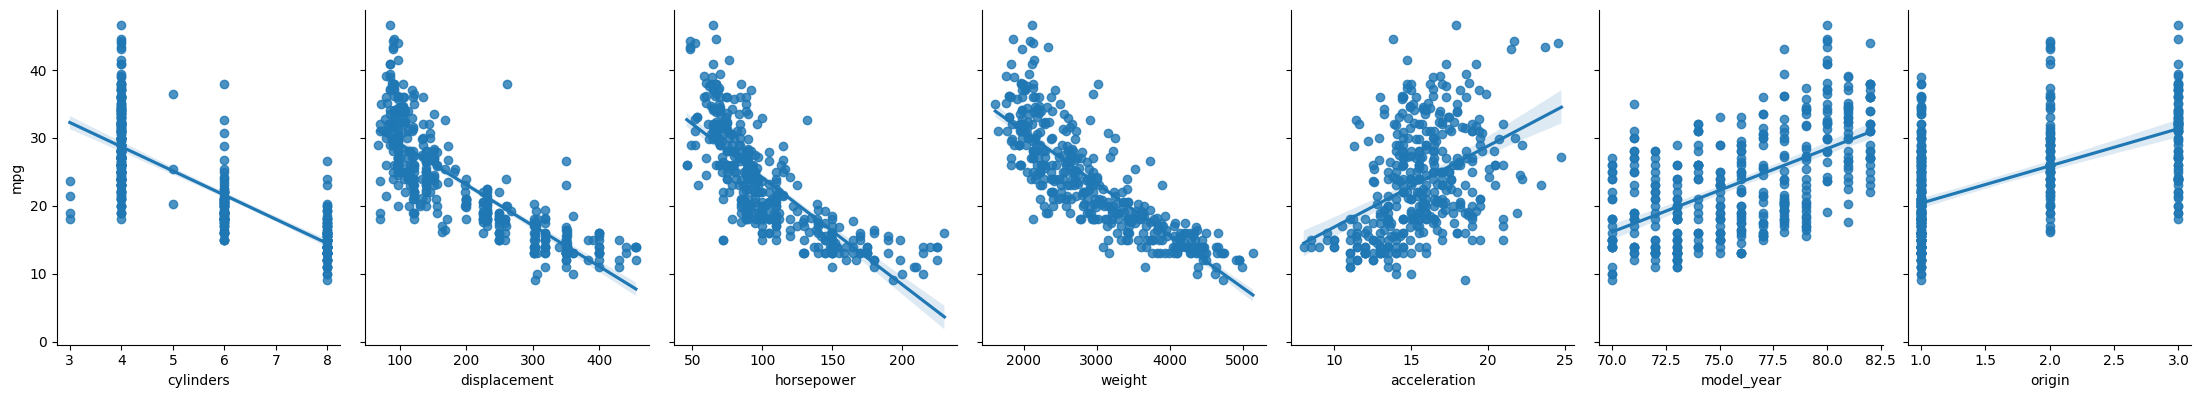

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df,
    x_vars=[
        "cylinders",
        "displacement",
        "horsepower",
        "weight",
        "acceleration",
        "model_year",
        "origin"
    ],
    y_vars="mpg",
    height=4,
    aspect=0.8,
    kind="reg"
)

plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

### Step 6. Relationship between each feature and mpg

1. **x = cylinders** and **y = mpg**  
   → Decreasing relationship  
   As the number of cylinders increases, fuel efficiency (mpg) decreases.

2. **x = displacement** and **y = mpg**  
   → Decreasing relationship  
   Larger engine displacement leads to lower fuel efficiency.

3. **x = horsepower** and **y = mpg**  
   → Decreasing relationship  
   Cars with more horsepower tend to consume more fuel, resulting in lower mpg.

4. **x = weight** and **y = mpg**  
   → Decreasing relationship  
   Heavier cars generally have lower fuel efficiency.

5. **x = acceleration** and **y = mpg**  
   → Weak increasing relationship (slight positive trend)  
   Cars

### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

# numerical features
num_features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

# categorical feature
cat_features = ["origin"]

# preprocessing
preprocessor = ColumnTransformer([
    
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer()),
            ("scaler", StandardScaler())
        ]),
        num_features
    ),
    
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder())
        ]),
        cat_features
    )
])

# final pipeline
model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

### Step 8. Split the dataset into train and test sets

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### Step 9.a Fit the pipeline on the training set

In [27]:
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [30]:
# coefficients
coef = model.named_steps["regressor"].coef_

# intercept
bias = model.named_steps["regressor"].intercept_

print("Coefficients:")
print(coef)

print("\nBias (intercept):")
print(bias)

Coefficients:
[-0.27585901  2.01592928 -0.49901149 -5.9336702   0.20066718  2.9759995
 -1.86500661  1.07511444  0.78989217]

Bias (intercept):
24.404408818096233


### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

In [31]:
# موقع weight في قائمة features
feature_names = (
    model.named_steps["preprocessing"]
    .get_feature_names_out()
)

for i, name in enumerate(feature_names):
    print(i, name)

0 num__cylinders
1 num__displacement
2 num__horsepower
3 num__weight
4 num__acceleration
5 num__model_year
6 cat__origin_1
7 cat__origin_2
8 cat__origin_3


### Step 10. Evaluate the pipeline on the test set

In [29]:
print(model.score(X_test, y_test))

0.8449024450695695
